### Imports and setups

In [1]:
# Keep in mind that I am using MindSpore + CIFAR-10 dataset, for model I am using TinyViT + Random Search
import os
import time
import glob
import math
import json
import random
from pathlib import Path
from functools import partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mindspore as ms
from mindspore import nn, ops, Tensor, context
from mindspore import dtype as mstype
from mindspore import Parameter
import mindspore.dataset as ds
import mindspore.dataset.vision as vision
import mindspore.dataset.transforms as c_transforms
from mindspore.common import initializer as init


Setup was done


In [2]:
# For my own convenience I am using reproducability to not see everytime different results
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    ms.set_seed(seed)

set_seed(42)


Checking the device, whether I'm using the GPU or not

In [3]:
# Checking the device, whether I am using the GPU or not
try:
    context.set_context(mode=context.GRAPH_MODE, device_target='GPU')
    device_target = 'GPU'
except RuntimeError:
    context.set_context(mode=context.GRAPH_MODE, device_target='CPU')
    device_target = 'CPU'

print('MindSpore device target:', device_target)


cuda


### Data preparation and preprocessing

I'm doing the following 2 lines of codes to normalize my images

In [4]:
cifar10_mean = (0.4914, 0.4822, 0.4465)
cifar10_std  = (0.2470, 0.2435, 0.2616)

I applied Random Augmentation, it is a powerful augmentation from Google Research

In [5]:
def get_transforms(use_randaugment=True, cutout=False):
    train_ops = [
        vision.RandomResizedCrop((32, 32), scale=(0.8, 1.0)),
        vision.RandomHorizontalFlip(prob=0.5),
        vision.RandomColorAdjust(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    ]
    if use_randaugment and hasattr(vision, 'RandAugment'):
        train_ops.append(vision.RandAugment(num_ops=2, magnitude=9))
    train_ops.extend([
        vision.ToTensor(),
        vision.Normalize(mean=cifar10_mean, std=cifar10_std, is_hwc=False),
    ])
    if cutout and hasattr(vision, 'CutOut'):
        train_ops.append(vision.CutOut(num_holes=1, length=8))

    test_ops = [
        vision.Resize((32, 32)),
        vision.ToTensor(),
        vision.Normalize(mean=cifar10_mean, std=cifar10_std, is_hwc=False),
    ]
    train_transform = c_transforms.Compose(train_ops)
    test_transform = c_transforms.Compose(test_ops)
    return train_transform, test_transform


In [6]:
def get_cifar10_loaders_with_val(batch_size=128, data_dir='./data',
                                 use_randaugment=True, cutout=False,
                                 val_fraction=0.1, seed=42, num_workers=4):
    train_transform, test_transform = get_transforms(use_randaugment, cutout)
    ds.config.set_seed(seed)

    train_dataset = ds.Cifar10Dataset(data_dir, usage='train', shuffle=True)
    test_dataset = ds.Cifar10Dataset(data_dir, usage='test', shuffle=False)

    if val_fraction > 0.0:
        splits = [1 - val_fraction, val_fraction]
        train_dataset, val_dataset = train_dataset.split(splits, randomize=True)
    else:
        val_dataset = None

    type_cast = c_transforms.TypeCast(mstype.int32)

    train_dataset = train_dataset.map(operations=train_transform, input_columns='image', num_parallel_workers=num_workers)
    train_dataset = train_dataset.map(operations=type_cast, input_columns='label', num_parallel_workers=num_workers)
    train_loader = train_dataset.batch(batch_size, drop_remainder=True)

    if val_dataset is not None:
        val_dataset = val_dataset.map(operations=test_transform, input_columns='image', num_parallel_workers=num_workers)
        val_dataset = val_dataset.map(operations=type_cast, input_columns='label', num_parallel_workers=num_workers)
        val_loader = val_dataset.batch(batch_size, drop_remainder=False)
    else:
        val_loader = None

    test_dataset = test_dataset.map(operations=test_transform, input_columns='image', num_parallel_workers=num_workers)
    test_dataset = test_dataset.map(operations=type_cast, input_columns='label', num_parallel_workers=num_workers)
    test_loader = test_dataset.batch(batch_size, drop_remainder=False)
    return train_loader, val_loader, test_loader


### TinyViT 1-layer Model

In [7]:
class MultiHeadSelfAttention(nn.Cell):
    def __init__(self, emb_dim=128, heads=4, dropout=0.1):
        super().__init__()
        if emb_dim % heads != 0:
            raise ValueError('Embedding dimension must be divisible by number of heads.')
        self.num_heads = heads
        self.head_dim = emb_dim // heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Dense(emb_dim, emb_dim * 3)
        keep_prob = 1.0 - dropout
        self.attn_drop = nn.Dropout(keep_prob=keep_prob)
        self.proj = nn.Dense(emb_dim, emb_dim)
        self.proj_drop = nn.Dropout(keep_prob=keep_prob)
        self.softmax = nn.Softmax(axis=-1)

    def construct(self, x):
        b, n, c = x.shape
        qkv = self.qkv(x)
        qkv = ops.reshape(qkv, (b, n, 3, self.num_heads, self.head_dim))
        qkv = ops.transpose(qkv, (2, 0, 3, 1, 4))
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = ops.matmul(q, ops.transpose(k, (0, 1, 3, 2))) * self.scale
        attn = self.softmax(attn)
        attn = self.attn_drop(attn)
        out = ops.matmul(attn, v)
        out = ops.transpose(out, (0, 2, 1, 3))
        out = ops.reshape(out, (b, n, c))
        out = self.proj(out)
        out = self.proj_drop(out)
        return out


class TinyViT(nn.Cell):
    def __init__(self, img_size=32, patch_size=4, in_ch=3, emb_dim=128, mlp_dim=256, heads=4, dropout=0.1, num_classes=10):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.in_ch = in_ch
        self.emb_dim = emb_dim
        self.num_patches = (img_size // patch_size) ** 2
        self.patch_dim = in_ch * patch_size * patch_size

        self.patch_embed = nn.Dense(self.patch_dim, emb_dim)
        init_shape = (1, 1, emb_dim)
        self.cls_token = Parameter(init.initializer(init.Normal(sigma=0.02), init_shape, mstype.float32))
        self.pos_embed = Parameter(init.initializer(init.Normal(sigma=0.02), (1, self.num_patches + 1, emb_dim), mstype.float32))

        self.attn = MultiHeadSelfAttention(emb_dim=emb_dim, heads=heads, dropout=dropout)
        keep_prob = 1.0 - dropout
        self.mlp = nn.SequentialCell([
            nn.Dense(emb_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(keep_prob=keep_prob),
            nn.Dense(mlp_dim, emb_dim),
            nn.Dropout(keep_prob=keep_prob),
        ])
        self.norm1 = nn.LayerNorm((emb_dim,))
        self.norm2 = nn.LayerNorm((emb_dim,))
        self.norm_out = nn.LayerNorm((emb_dim,))
        self.head = nn.Dense(emb_dim, num_classes)

    def _patchify(self, x):
        b, c, h, w = x.shape
        p = self.patch_size
        x = ops.reshape(x, (b, c, h // p, p, w // p, p))
        x = ops.transpose(x, (0, 2, 4, 1, 3, 5))
        x = ops.reshape(x, (b, self.num_patches, self.patch_dim))
        return x

    def construct(self, x):
        b = x.shape[0]
        x = self._patchify(x)
        x = self.patch_embed(x)
        cls_tokens = ops.tile(self.cls_token, (b, 1, 1))
        x = ops.concat((cls_tokens, x), axis=1)
        x = x + self.pos_embed
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        x = self.norm_out(x[:, 0])
        x = self.head(x)
        return x


### Training Utilities

In [8]:
def mixup_data(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y, None, 1.0
    lam = np.random.beta(alpha, alpha)
    batch_size = x.shape[0]
    perm = np.random.permutation(batch_size)
    perm_tensor = Tensor(perm, mstype.int32)
    gather = ops.Gather()
    x_shuffled = gather(x, perm_tensor, 0)
    y_shuffled = gather(y, perm_tensor, 0)
    mixed_x = lam * x + (1.0 - lam) * x_shuffled
    return mixed_x, y, y_shuffled, lam


In [9]:
def one_hot_targets(labels, num_classes, label_smoothing=0.0):
    on_value = 1.0 - label_smoothing + (label_smoothing / num_classes)
    off_value = label_smoothing / num_classes
    targets = ops.one_hot(labels, num_classes, on_value=on_value, off_value=off_value)
    return ops.cast(targets, mstype.float32)


def compute_loss_from_logits(logits, targets):
    log_probs = ops.log_softmax(logits, axis=-1)
    loss = (-targets * log_probs).sum(axis=-1)
    return loss.mean()


def train_epoch(model, loader, optimizer, num_classes=10, use_mixup=False, mixup_alpha=0.2, label_smoothing=0.0):
    model.set_train()
    running_loss, correct, total = 0.0, 0, 0
    t0 = time.time()

    def forward_fn(inputs, targets):
        logits = model(inputs)
        loss = compute_loss_from_logits(logits, targets)
        return loss, logits

    grad_fn = ops.value_and_grad(forward_fn, None, optimizer.parameters, has_aux=True)

    for images, labels in loader.create_tuple_iterator():
        if use_mixup and mixup_alpha > 0:
            images, labels_a, labels_b, lam = mixup_data(images, labels, mixup_alpha)
            targets_a = one_hot_targets(labels_a, num_classes, label_smoothing)
            targets_b = one_hot_targets(labels_b, num_classes, label_smoothing)
            targets = lam * targets_a + (1.0 - lam) * targets_b
            labels_for_acc = labels_a
        else:
            targets = one_hot_targets(labels, num_classes, label_smoothing)
            labels_for_acc = labels
        (loss, logits), grads = grad_fn(images, targets)
        optimizer(grads)
        batch_size = images.shape[0]
        running_loss += float(loss.asnumpy()) * batch_size
        preds = ops.argmax(logits, axis=1)
        correct += int((preds == labels_for_acc).asnumpy().sum())
        total += batch_size

    epoch_time = time.time() - t0
    return running_loss / max(total, 1), correct / max(total, 1), epoch_time


def validate(model, loader, num_classes=10, label_smoothing=0.0):
    if loader is None:
        return float('nan'), float('nan'), 0.0
    model.set_train(False)
    running_loss, correct, total = 0.0, 0, 0
    t0 = time.time()

    for images, labels in loader.create_tuple_iterator():
        logits = model(images)
        targets = one_hot_targets(labels, num_classes, label_smoothing)
        loss = compute_loss_from_logits(logits, targets)
        batch_size = images.shape[0]
        running_loss += float(loss.asnumpy()) * batch_size
        preds = ops.argmax(logits, axis=1)
        correct += int((preds == labels).asnumpy().sum())
        total += batch_size

    elapsed = time.time() - t0
    return running_loss / max(total, 1), correct / max(total, 1), elapsed


In [10]:
# Legacy validate helper replaced by MindSpore implementation above.


### Baseline TinyViT (1 layer) run

Here by "baseline" I mean the model that is not applied any hyperparameter optimizations. I decided to train the baseline for 20 epochs, but the hyperparameter opimization will be applied more than that

In [11]:
baseline_config = {
    "patch_size": 4,
    "emb_dim": 64,
    "mlp_mult": 2,
    "heads": 4,
    "dropout": 0.1,
    "lr": 3e-4,
    "weight_decay": 0.05,
    "batch_size": 128,
    "mixup_alpha": 0.0,
    "label_smoothing": 0.0,
    "randaugment": True,
    "cutout": False,
    "max_epochs": 20 # from time to time I'm correcting it
}


train_loader, val_loader, test_loader = get_cifar10_loaders_with_val(
    batch_size=baseline_config["batch_size"],
    use_randaugment=baseline_config["randaugment"],
    cutout=baseline_config["cutout"],
    val_fraction=0.1
)

100%|██████████| 170M/170M [00:04<00:00, 34.8MB/s]


In [12]:
model = TinyViT(img_size=32,
                patch_size=baseline_config[patch_size],
                emb_dim=baseline_config[emb_dim],
                mlp_dim=baseline_config[emb_dim] * baseline_config[mlp_mult],
                heads=baseline_config[heads],
                dropout=baseline_config[dropout])

optimizer = nn.AdamWeightDecay(params=model.trainable_params(),
                               learning_rate=baseline_config[lr],
                               weight_decay=baseline_config[weight_decay])

history = {epoch: [], train_loss: [], train_acc: [], val_loss: [], val_acc: [], epoch_time: []}
total_train_time = 0.0
best_val_acc = 0.0
best_epoch = 0

for epoch in range(baseline_config[max_epochs]):
    t_loss, t_acc, epoch_time = train_epoch(
        model,
        train_loader,
        optimizer,
        num_classes=10,
        use_mixup=(baseline_config[mixup_alpha] > 0.0),
        mixup_alpha=baseline_config[mixup_alpha],
        label_smoothing=baseline_config[label_smoothing]
    )
    v_loss, v_acc, _ = validate(
        model,
        val_loader,
        num_classes=10,
        label_smoothing=baseline_config[label_smoothing]
    )
    total_train_time += epoch_time
    history[epoch].append(epoch + 1)
    history[train_loss].append(t_loss)
    history[train_acc].append(t_acc)
    history[val_loss].append(v_loss)
    history[val_acc].append(v_acc)
    history[epoch_time].append(epoch_time)
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        best_epoch = epoch + 1
        ms.save_checkpoint(model, baseline_best_checkpoint.ckpt)
    print(f'Epoch {epoch+1}/{baseline_config[max_epochs]} | train_acc={t_acc:.4f} | val_acc={v_acc:.4f}')


Epoch 1/20 | train_acc=0.1961 | val_acc=0.2702
Epoch 2/20 | train_acc=0.2396 | val_acc=0.3286
Epoch 3/20 | train_acc=0.2670 | val_acc=0.3444
Epoch 4/20 | train_acc=0.2842 | val_acc=0.3662
Epoch 5/20 | train_acc=0.3019 | val_acc=0.3790
Epoch 6/20 | train_acc=0.3128 | val_acc=0.3986
Epoch 7/20 | train_acc=0.3222 | val_acc=0.4062
Epoch 8/20 | train_acc=0.3330 | val_acc=0.4100
Epoch 9/20 | train_acc=0.3430 | val_acc=0.4276
Epoch 10/20 | train_acc=0.3446 | val_acc=0.4488
Epoch 11/20 | train_acc=0.3578 | val_acc=0.4550
Epoch 12/20 | train_acc=0.3599 | val_acc=0.4614
Epoch 13/20 | train_acc=0.3626 | val_acc=0.4608
Epoch 14/20 | train_acc=0.3680 | val_acc=0.4620
Epoch 15/20 | train_acc=0.3683 | val_acc=0.4704
Epoch 16/20 | train_acc=0.3711 | val_acc=0.4648
Epoch 17/20 | train_acc=0.3740 | val_acc=0.4772
Epoch 18/20 | train_acc=0.3789 | val_acc=0.4630
Epoch 19/20 | train_acc=0.3803 | val_acc=0.4798
Epoch 20/20 | train_acc=0.3812 | val_acc=0.4856


Saving my model and history for future usage

In [13]:
os.makedirs(baseline_results, exist_ok=True)
ms.save_checkpoint(model, baseline_results/tinyvit_baseline_final.ckpt)
with open(baseline_results/history.json, w) as f:
    json.dump(history, f, indent=2)

baseline_summary = {
    best_val_acc: float(best_val_acc),
    best_epoch: int(best_epoch),
    total_train_time_s: float(total_train_time),
    config: baseline_config
}
with open(baseline_results/summary.json, w) as f:
    json.dump(baseline_summary, f, indent=2)


Let's plot what we've got for baseline model

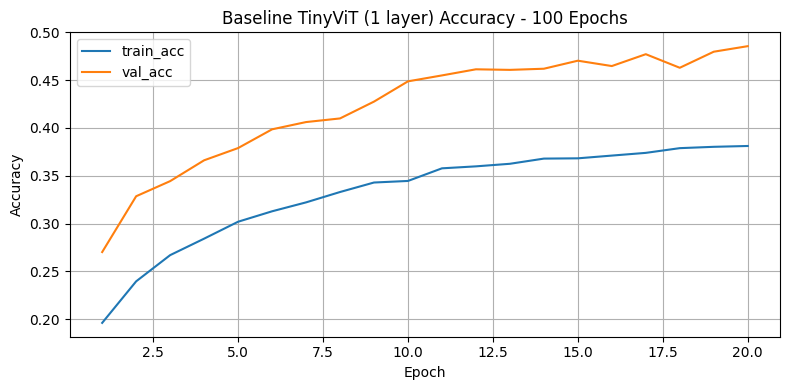

In [14]:
plt.figure(figsize=(8,4))
plt.plot(history["epoch"], history["train_acc"], label="train_acc")
plt.plot(history["epoch"], history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline TinyViT (1 layer) Accuracy - 100 Epochs")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig("baseline_results/baseline_acc_plot.png")
plt.show()

### Here is the beginning of my Hyperparameter Optimization

In [15]:
def sample_random_config():
    """Sample a random configuration from predefined ranges."""
    config = {}
    config["patch_size"]   = random.choice([2, 4])
    config["emb_dim"]      = random.choice([64, 96, 128])
    config["mlp_mult"]     = random.choice([2, 3, 4])
    config["heads"]        = random.choice([2, 4, 8])
    config["dropout"]      = random.choice([0.0, 0.1, 0.2, 0.3])

    lr_log_min, lr_log_max = math.log10(1e-4), math.log10(3e-3)
    wd_log_min, wd_log_max = math.log10(1e-4), math.log10(1e-1)

    config["lr"] = 10 ** random.uniform(lr_log_min, lr_log_max)
    config["weight_decay"] = 10 ** random.uniform(wd_log_min, wd_log_max)

    config["batch_size"]   = random.choice([64, 128, 256])
    config["mixup_alpha"]  = random.choice([0.0, 0.1, 0.2, 0.3])
    config["label_smoothing"] = random.choice([0.0, 0.05, 0.1])
    config["randaugment"]  = random.choice([True, False])
    config["cutout"]       = random.choice([True, False])
    config["max_epochs"]   = 30  # from time to time I changing it, to see whether I can afford myself that time

    return config

In [16]:
def build_loaders_for_config(config):
    train_loader, val_loader, test_loader = get_cifar10_loaders_with_val(
        batch_size    = config["batch_size"],
        use_randaugment = config["randaugment"],
        cutout        = config["cutout"],
        val_fraction  = 0.1,
        data_dir      = "./data",
        num_workers   = 4
    )
    return train_loader, val_loader, test_loader

In [17]:
def build_model_for_config(config):
    mlp_dim = config[emb_dim] * config[mlp_mult]
    model = TinyViT(
        img_size=32,
        patch_size=config[patch_size],
        in_ch=3,
        emb_dim=config[emb_dim],
        mlp_dim=mlp_dim,
        heads=config[heads],
        dropout=config[dropout],
        num_classes=10
    )
    return model


In [18]:
def run_one_trial(trial_id, config):
    print(f"
========== Trial {trial_id} ==========")
    print("Config:")
    print(json.dumps(config, indent=2))

    set_seed(42 + trial_id)

    train_loader, val_loader, test_loader = build_loaders_for_config(config)

    model = build_model_for_config(config)

    optimizer = nn.AdamWeightDecay(
        params=model.trainable_params(),
        learning_rate=config["lr"],
        weight_decay=config["weight_decay"]
    )

    history = {"epoch": [], "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "epoch_time": []}
    best_val_acc = 0.0
    best_epoch = 0

    train_start_time = time.time()
    for epoch in range(config["max_epochs"]):
        t_loss, t_acc, epoch_time = train_epoch(
            model,
            train_loader,
            optimizer,
            num_classes=10,
            use_mixup=(config["mixup_alpha"] > 0.0),
            mixup_alpha=config["mixup_alpha"],
            label_smoothing=config["label_smoothing"]
        )
        v_loss, v_acc, _ = validate(
            model,
            val_loader,
            num_classes=10,
            label_smoothing=config["label_smoothing"]
        )
        history["epoch"].append(epoch + 1)
        history["train_loss"].append(t_loss)
        history["train_acc"].append(t_acc)
        history["val_loss"].append(v_loss)
        history["val_acc"].append(v_acc)
        history["epoch_time"].append(epoch_time)
        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_epoch = epoch + 1
        print(f"  Epoch {epoch+1}/{config['max_epochs']}: train_acc={t_acc:.4f}, val_acc={v_acc:.4f}")

    total_train_time = time.time() - train_start_time
    val_loss, val_acc, _ = validate(
        model, val_loader, num_classes=10, label_smoothing=config["label_smoothing"]
    )
    test_loss, test_acc, _ = validate(
        model, test_loader, num_classes=10, label_smoothing=config["label_smoothing"]
    )

    model.set_train(False)
    inf_start = time.time()
    for xb, _ in test_loader.create_tuple_iterator():
        _ = model(xb)
    inference_time = time.time() - inf_start

    result = {
        "trial_id": trial_id,
        "config": config,
        "best_val_acc": float(best_val_acc),
        "best_epoch": int(best_epoch),
        "final_val_acc": float(val_acc),
        "test_acc": float(test_acc),
        "total_train_time_s": float(total_train_time),
        "inference_time_s": float(inference_time),
        "history": history
    }

    f_tuple = (
        config["patch_size"],
        1,
        config["emb_dim"],
        config["emb_dim"] * config["mlp_mult"],
        config["heads"]
    )
    print("
  Trial summary:")
    print(f"    f = (Patch={f_tuple[0]}, Layers={f_tuple[1]}, D={f_tuple[2]}, MLP={f_tuple[3]}, Heads={f_tuple[4]})")
    print(f"    Training HPs: lr={config['lr']:.5f}, weight_decay={config['weight_decay']:.5f}, batch_size={config['batch_size']}, "
          f"dropout={config['dropout']}, mixup_alpha={config['mixup_alpha']}, label_smoothing={config['label_smoothing']}, "
          f"randaugment={config['randaugment']}, cutout={config['cutout']}")
    print(f"    Total training time: {total_train_time:.2f} s")
    print(f"    Inference time (full test set): {inference_time:.2f} s")
    print(f"    Best val acc: {best_val_acc:.4f} at epoch {best_epoch}")
    print(f"    Final val acc: {val_acc:.4f}, Test acc: {test_acc:.4f}")

    return result


In [19]:
num_trials = 8 # I should change this one to 32 combinations
results = []
best_result = None
best_val_acc_overall = -1.0

os.makedirs("random_search_results", exist_ok=True)

for trial_id in range(1, num_trials + 1):
    cfg = sample_random_config()
    res = run_one_trial(trial_id, cfg)
    results.append(res)

    if res["best_val_acc"] > best_val_acc_overall:
        best_val_acc_overall = res["best_val_acc"]
        best_result = res

        with open("random_search_results/best_tinyvit_randomsearch.json", "w") as fp:
            json.dump(res, fp, indent=2)



========== Trial 1 ==========
Config:
{
  "patch_size": 2,
  "emb_dim": 64,
  "mlp_mult": 4,
  "heads": 4,
  "dropout": 0.1,
  "lr": 0.0002136531624811125,
  "weight_decay": 0.01619621907336969,
  "batch_size": 256,
  "mixup_alpha": 0.0,
  "label_smoothing": 0.1,
  "randaugment": false,
  "cutout": true,
  "max_epochs": 30
}
  Epoch 1/30: train_acc=0.2086, val_acc=0.2588
  Epoch 2/30: train_acc=0.2601, val_acc=0.2820
  Epoch 3/30: train_acc=0.2763, val_acc=0.3034
  Epoch 4/30: train_acc=0.2984, val_acc=0.3256
  Epoch 5/30: train_acc=0.3206, val_acc=0.3634
  Epoch 6/30: train_acc=0.3468, val_acc=0.3958
  Epoch 7/30: train_acc=0.3604, val_acc=0.4076
  Epoch 8/30: train_acc=0.3715, val_acc=0.4036
  Epoch 9/30: train_acc=0.3829, val_acc=0.4220
  Epoch 10/30: train_acc=0.3907, val_acc=0.4316
  Epoch 11/30: train_acc=0.4004, val_acc=0.4392
  Epoch 12/30: train_acc=0.4072, val_acc=0.4494
  Epoch 13/30: train_acc=0.4150, val_acc=0.4556
  Epoch 14/30: train_acc=0.4233, val_acc=0.4564
  Epoch 1

### Visualization

In [20]:
records = []
for r in results:
    cfg = r["config"]
    records.append({
        "trial_id": r["trial_id"],
        "best_val_acc": r["best_val_acc"],
        "test_acc": r["test_acc"],
        "train_time_s": r["total_train_time_s"],
        "inference_time_s": r["inference_time_s"],
        "patch_size": cfg["patch_size"],
        "emb_dim": cfg["emb_dim"],
        "mlp_mult": cfg["mlp_mult"],
        "heads": cfg["heads"],
        "dropout": cfg["dropout"],
        "lr": cfg["lr"],
        "weight_decay": cfg["weight_decay"],
        "batch_size": cfg["batch_size"],
        "mixup_alpha": cfg["mixup_alpha"],
        "label_smoothing": cfg["label_smoothing"],
        "randaugment": cfg["randaugment"],
        "cutout": cfg["cutout"],
    })

df = pd.DataFrame.from_records(records)
df.to_csv("random_search_results/random_search_summary.csv", index=False)

print("\nRandom search summary (per trial):")
print(df[[
    "trial_id", "best_val_acc", "test_acc", "train_time_s",
    "patch_size", "emb_dim", "mlp_mult", "heads", "lr", "batch_size"
]])


Random search summary (per trial):
   trial_id  best_val_acc  test_acc  train_time_s  patch_size  emb_dim  \
0         1        0.5040    0.5065    587.088377           2       64   
1         2        0.4816    0.4838    620.205302           2       96   
2         3        0.5616    0.5548    781.072258           4      128   
3         4        0.5532    0.5469    573.595162           4       96   
4         5        0.5390    0.5443    735.341854           2       96   
5         6        0.5040    0.5019    700.470916           4       64   
6         7        0.5136    0.5070    739.350310           4       64   
7         8        0.5088    0.4841    615.155343           2       96   

   mlp_mult  heads        lr  batch_size  
0         4      4  0.000214         256  
1         4      2  0.000352          64  
2         4      8  0.000182          64  
3         3      4  0.000280         128  
4         2      8  0.000866         256  
5         3      8  0.000697         12

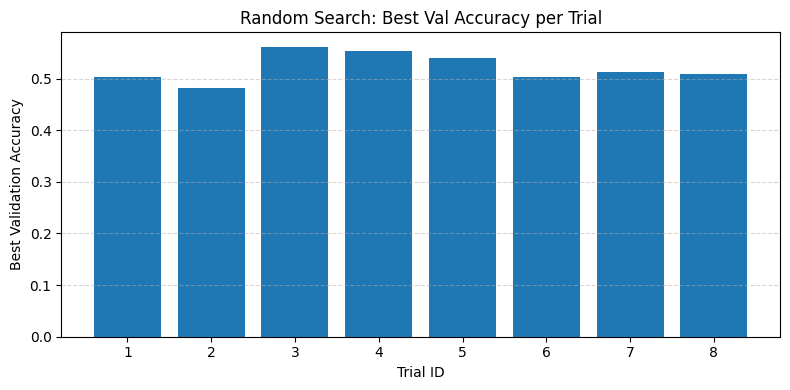

In [21]:
plt.figure(figsize=(8, 4))
plt.bar(df["trial_id"].astype(str), df["best_val_acc"])
plt.xlabel("Trial ID")
plt.ylabel("Best Validation Accuracy")
plt.title("Random Search: Best Val Accuracy per Trial")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("random_search_results/best_val_acc_per_trial.png")
plt.show()

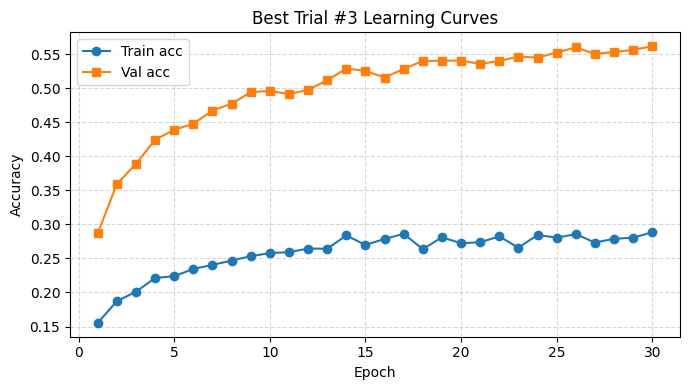

In [22]:
if best_result is not None:
    hist = best_result["history"]
    plt.figure(figsize=(7, 4))
    plt.plot(hist["epoch"], hist["train_acc"], marker="o", label="Train acc")
    plt.plot(hist["epoch"], hist["val_acc"], marker="s", label="Val acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Best Trial #{best_result['trial_id']} Learning Curves")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig("random_search_results/best_trial_learning_curves.png")
    plt.show()

In [23]:
with open("random_search_results/all_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("\n===================================")
print("Short summary of first 5 trials:")
print("===================================")
for res in results[:5]:
    cfg = res["config"]
    f_tuple = (
        cfg["patch_size"],
        1,
        cfg["emb_dim"],
        cfg["emb_dim"] * cfg["mlp_mult"],
        cfg["heads"]
    )
    print(f"\nTrial {res['trial_id']}:")
    print(f"  f = (Patch={f_tuple[0]}, Layers={f_tuple[1]}, "
          f"D={f_tuple[2]}, MLP={f_tuple[3]}, Heads={f_tuple[4]})")
    print(f"  Training HPs: lr={cfg['lr']:.5f}, "
          f"weight_decay={cfg['weight_decay']:.5f}, "
          f"batch_size={cfg['batch_size']}, "
          f"dropout={cfg['dropout']}, "
          f"mixup_alpha={cfg['mixup_alpha']}, "
          f"label_smoothing={cfg['label_smoothing']}, "
          f"randaugment={cfg['randaugment']}, cutout={cfg['cutout']}")
    print(f"  Best val acc: {res['best_val_acc']:.4f} (epoch {res['best_epoch']})")
    print(f"  Final val acc: {res['final_val_acc']:.4f}, "
          f"Test acc: {res['test_acc']:.4f}")
    print(f"  Total training time: {res['total_train_time_s']:.2f} s")
    print(f"  Inference time (test set): {res['inference_time_s']:.2f} s")


Short summary of first 5 trials:

Trial 1:
  f = (Patch=2, Layers=1, D=64, MLP=256, Heads=4)
  Training HPs: lr=0.00021, weight_decay=0.01620, batch_size=256, dropout=0.1, mixup_alpha=0.0, label_smoothing=0.1, randaugment=False, cutout=True
  Best val acc: 0.5040 (epoch 30)
  Final val acc: 0.5040, Test acc: 0.5065
  Total training time: 587.09 s
  Inference time (test set): 1.21 s

Trial 2:
  f = (Patch=2, Layers=1, D=96, MLP=384, Heads=2)
  Training HPs: lr=0.00035, weight_decay=0.01245, batch_size=64, dropout=0.3, mixup_alpha=0.3, label_smoothing=0.1, randaugment=False, cutout=True
  Best val acc: 0.4816 (epoch 28)
  Final val acc: 0.4764, Test acc: 0.4838
  Total training time: 620.21 s
  Inference time (test set): 1.31 s

Trial 3:
  f = (Patch=4, Layers=1, D=128, MLP=512, Heads=8)
  Training HPs: lr=0.00018, weight_decay=0.00047, batch_size=64, dropout=0.0, mixup_alpha=0.1, label_smoothing=0.0, randaugment=True, cutout=True
  Best val acc: 0.5616 (epoch 30)
  Final val acc: 0.561

In [24]:
print("\n===================================")
print("Best configuration over all trials")
print("===================================")
if best_result is not None:
    cfg = best_result["config"]
    f_tuple = (
        cfg["patch_size"],
        1,
        cfg["emb_dim"],
        cfg["emb_dim"] * cfg["mlp_mult"],
        cfg["heads"]
    )
    print(f"Best validation accuracy: {best_result['best_val_acc']:.4f} "
          f"(epoch {best_result['best_epoch']})")
    print(f"Corresponding test accuracy: {best_result['test_acc']:.4f}")
    print(f"f = (Patch={f_tuple[0]}, Layers={f_tuple[1]}, "
          f"D={f_tuple[2]}, MLP={f_tuple[3]}, Heads={f_tuple[4]})")
    print("Training HPs:")
    print(f"  lr={cfg['lr']:.5f}, weight_decay={cfg['weight_decay']:.5f}")
    print(f"  batch_size={cfg['batch_size']}, dropout={cfg['dropout']}")
    print(f"  mixup_alpha={cfg['mixup_alpha']}, "
          f"label_smoothing={cfg['label_smoothing']}")
    print(f"  randaugment={cfg['randaugment']}, cutout={cfg['cutout']}")
    print(f"  Total training time: {best_result['total_train_time_s']:.2f} s")
    print(f"  Inference time (test set): {best_result['inference_time_s']:.2f} s")
else:
    print("No trials were run.")


Best configuration over all trials
Best validation accuracy: 0.5616 (epoch 30)
Corresponding test accuracy: 0.5548
f = (Patch=4, Layers=1, D=128, MLP=512, Heads=8)
Training HPs:
  lr=0.00018, weight_decay=0.00047
  batch_size=64, dropout=0.0
  mixup_alpha=0.1, label_smoothing=0.0
  randaugment=True, cutout=True
  Total training time: 781.07 s
  Inference time (test set): 1.26 s


In [25]:
records = []
for r in results:
    cfg = r["config"]
    records.append({
        "trial_id": r["trial_id"],
        "best_val_acc": r["best_val_acc"],
        "test_acc": r["test_acc"],
        "total_train_time_s": r["total_train_time_s"],
        "inference_time_s": r["inference_time_s"],
        "patch_size": cfg["patch_size"],
        "emb_dim": cfg["emb_dim"],
        "mlp_mult": cfg["mlp_mult"],
        "heads": cfg["heads"],
        "dropout": cfg["dropout"],
        "lr": cfg["lr"],
        "weight_decay": cfg["weight_decay"],
        "batch_size": cfg["batch_size"],
        "mixup_alpha": cfg["mixup_alpha"],
        "label_smoothing": cfg["label_smoothing"],
        "randaugment": cfg["randaugment"],
        "cutout": cfg["cutout"],
    })

df = pd.DataFrame.from_records(records)

df_sorted = df.sort_values("best_val_acc", ascending=False)

df_top5 = df_sorted.head(5).reset_index(drop=True)

print("\n===================================")
print("Top-5 search spaces (by validation accuracy)")
print("===================================")

for idx, row in df_top5.iterrows():
    f_tuple = (
        row["patch_size"],
        1,  # Layers = 1 (fixed in TinyViT)
        row["emb_dim"],
        row["emb_dim"] * row["mlp_mult"],
        row["heads"]
    )
    print(f"\nRank {idx+1} (Trial {row['trial_id']}):")
    print(f"  f = (Patch={f_tuple[0]}, Layers={f_tuple[1]}, "
          f"D={f_tuple[2]}, MLP={f_tuple[3]}, Heads={f_tuple[4]})")
    print(f"  Training HPs:")
    print(f"    lr={row['lr']:.5f}, weight_decay={row['weight_decay']:.5f}")
    print(f"    batch_size={row['batch_size']}, dropout={row['dropout']}")
    print(f"    mixup_alpha={row['mixup_alpha']}, "
          f"label_smoothing={row['label_smoothing']}")
    print(f"    randaugment={row['randaugment']}, cutout={row['cutout']}")
    print(f"  Performance:")
    print(f"    Best val acc = {row['best_val_acc']:.4f}")
    print(f"    Test acc     = {row['test_acc']:.4f}")
    print(f"    Total training time = {row['total_train_time_s']:.2f} s")
    print(f"    Inference time (test set) = {row['inference_time_s']:.2f} s")

best_among_top5 = df_top5.sort_values("test_acc", ascending=False).iloc[0]

print("\n===================================")
print("Best TEST score among Top-5 search spaces")
print("===================================")

f_best = (
    best_among_top5["patch_size"],
    1,
    best_among_top5["emb_dim"],
    best_among_top5["emb_dim"] * best_among_top5["mlp_mult"],
    best_among_top5["heads"]
)

print(f"Best test accuracy (among Top-5) = {best_among_top5['test_acc']:.4f}")
print(f"Achieved by Trial {int(best_among_top5['trial_id'])}")
print(f"f = (Patch={f_best[0]}, Layers={f_best[1]}, "
      f"D={f_best[2]}, MLP={f_best[3]}, Heads={f_best[4]})")
print("Training HPs:")
print(f"  lr={best_among_top5['lr']:.5f}, "
      f"weight_decay={best_among_top5['weight_decay']:.5f}")
print(f"  batch_size={best_among_top5['batch_size']}, "
      f"dropout={best_among_top5['dropout']}")
print(f"  mixup_alpha={best_among_top5['mixup_alpha']}, "
      f"label_smoothing={best_among_top5['label_smoothing']}")
print(f"  randaugment={best_among_top5['randaugment']}, "
      f"cutout={best_among_top5['cutout']}")
print(f"  Total training time: {best_among_top5['total_train_time_s']:.2f} s")
print(f"  Inference time (test set): {best_among_top5['inference_time_s']:.2f} s")


Top-5 search spaces (by validation accuracy)

Rank 1 (Trial 3):
  f = (Patch=4, Layers=1, D=128, MLP=512, Heads=8)
  Training HPs:
    lr=0.00018, weight_decay=0.00047
    batch_size=64, dropout=0.0
    mixup_alpha=0.1, label_smoothing=0.0
    randaugment=True, cutout=True
  Performance:
    Best val acc = 0.5616
    Test acc     = 0.5548
    Total training time = 781.07 s
    Inference time (test set) = 1.26 s

Rank 2 (Trial 4):
  f = (Patch=4, Layers=1, D=96, MLP=288, Heads=4)
  Training HPs:
    lr=0.00028, weight_decay=0.00012
    batch_size=128, dropout=0.0
    mixup_alpha=0.0, label_smoothing=0.0
    randaugment=False, cutout=True
  Performance:
    Best val acc = 0.5532
    Test acc     = 0.5469
    Total training time = 573.60 s
    Inference time (test set) = 1.18 s

Rank 3 (Trial 5):
  f = (Patch=2, Layers=1, D=96, MLP=192, Heads=8)
  Training HPs:
    lr=0.00087, weight_decay=0.00029
    batch_size=256, dropout=0.1
    mixup_alpha=0.0, label_smoothing=0.0
    randaugment=Tr

## So the best accuracy is 55.48%

## Smart Glasses Dataset & Label Synchronization
These cells load the shared `Smart_Glasses_For_Blind_People/labels.txt`, build folder-based
MindSpore dataloaders for the smart-glasses dataset, fine-tune TinyViT, and export a MindIR
file that can be converted to a MindSpore Lite `.mslite` for Raspberry Pi deployment.

In [ ]:
SMART_GLASSES_ROOT = Path('Smart_Glasses_For_Blind_People')
LABELS_PATH = SMART_GLASSES_ROOT / 'labels.txt'

def load_smart_glasses_labels(path: Path) -> list[str]:
    labels = []
    for raw in path.read_text(encoding='utf-8').splitlines():
        item = raw.strip()
        if item:
            labels.append(item)
    if not labels:
        raise ValueError(f'No labels found in {path}')
    return labels

glasses_labels = load_smart_glasses_labels(LABELS_PATH)
num_glasses_classes = len(glasses_labels)
print(f'Loaded {num_glasses_classes} smart-glasses classes: {glasses_labels}')

In [ ]:
GLASSES_DATA_ROOT = SMART_GLASSES_ROOT / 'dataset'
GLASSES_RESULTS_DIR = SMART_GLASSES_ROOT / 'train_runs'
GLASSES_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def build_glasses_loaders(batch_size=32, use_randaugment=True, cutout=False, num_workers=2):
    if not GLASSES_DATA_ROOT.exists():
        raise FileNotFoundError(
            f'Expected a dataset folder at {GLASSES_DATA_ROOT}. Create train/val/test subfolders first.'
        )
    train_dir = GLASSES_DATA_ROOT / 'train'
    val_dir = GLASSES_DATA_ROOT / 'val'
    test_dir = GLASSES_DATA_ROOT / 'test'
    required_dirs = [train_dir, val_dir, test_dir]
    missing = [p for p in required_dirs if not p.exists()]
    if missing:
        raise FileNotFoundError(f'Missing dataset split folders: {missing}')

    class_indexing = {name: idx for idx, name in enumerate(glasses_labels)}
    train_ds = ds.ImageFolderDatasetV2(str(train_dir), shuffle=True, decode=True, class_indexing=class_indexing)
    val_ds = ds.ImageFolderDatasetV2(str(val_dir), shuffle=False, decode=True, class_indexing=class_indexing)
    test_ds = ds.ImageFolderDatasetV2(str(test_dir), shuffle=False, decode=True, class_indexing=class_indexing)

    train_transform, test_transform = get_transforms(use_randaugment, cutout)
    type_cast = c_transforms.TypeCast(mstype.int32)

    train_ds = train_ds.map(operations=train_transform, input_columns='image', num_parallel_workers=num_workers)
    train_ds = train_ds.map(operations=type_cast, input_columns='label', num_parallel_workers=num_workers)
    train_loader = train_ds.batch(batch_size, drop_remainder=True)

    val_ds = val_ds.map(operations=test_transform, input_columns='image', num_parallel_workers=num_workers)
    val_ds = val_ds.map(operations=type_cast, input_columns='label', num_parallel_workers=num_workers)
    val_loader = val_ds.batch(batch_size, drop_remainder=False)

    test_ds = test_ds.map(operations=test_transform, input_columns='image', num_parallel_workers=num_workers)
    test_ds = test_ds.map(operations=type_cast, input_columns='label', num_parallel_workers=num_workers)
    test_loader = test_ds.batch(batch_size, drop_remainder=False)
    return train_loader, val_loader, test_loader


glasses_config = baseline_config.copy()
glasses_config.update({
    'num_classes': num_glasses_classes,
    'batch_size': 32,
    'max_epochs': 40,
})

glasses_train_loader, glasses_val_loader, glasses_test_loader = build_glasses_loaders(
    batch_size=glasses_config['batch_size'],
    use_randaugment=glasses_config['randaugment'],
    cutout=glasses_config['cutout'],
)
print('Smart-glasses loaders ready:', glasses_config['num_classes'], 'classes')

In [ ]:
glasses_model = TinyViT(
    img_size=32,
    patch_size=glasses_config['patch_size'],
    emb_dim=glasses_config['emb_dim'],
    mlp_dim=glasses_config['emb_dim'] * glasses_config['mlp_mult'],
    heads=glasses_config['heads'],
    dropout=glasses_config['dropout'],
    num_classes=glasses_config['num_classes']
)

glasses_optimizer = nn.AdamWeightDecay(
    params=glasses_model.trainable_params(),
    learning_rate=glasses_config['lr'],
    weight_decay=glasses_config['weight_decay']
)

glasses_history = {"epoch": [], "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "epoch_time": []}
smart_best_ckpt = GLASSES_RESULTS_DIR / 'tinyvit_glasses_best.ckpt'
best_val_acc = 0.0
best_epoch = 0
total_train_time = 0.0

for epoch in range(glasses_config['max_epochs']):
    t_loss, t_acc, epoch_time = train_epoch(
        glasses_model,
        glasses_train_loader,
        glasses_optimizer,
        num_classes=glasses_config['num_classes'],
        use_mixup=(glasses_config['mixup_alpha'] > 0.0),
        mixup_alpha=glasses_config['mixup_alpha'],
        label_smoothing=glasses_config['label_smoothing']
    )
    v_loss, v_acc, _ = validate(
        glasses_model,
        glasses_val_loader,
        num_classes=glasses_config['num_classes'],
        label_smoothing=glasses_config['label_smoothing']
    )
    glasses_history['epoch'].append(epoch + 1)
    glasses_history['train_loss'].append(t_loss)
    glasses_history['train_acc'].append(t_acc)
    glasses_history['val_loss'].append(v_loss)
    glasses_history['val_acc'].append(v_acc)
    glasses_history['epoch_time'].append(epoch_time)
    total_train_time += epoch_time
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        best_epoch = epoch + 1
        ms.save_checkpoint(glasses_model, str(smart_best_ckpt))
    print(f"Smart glasses Epoch {epoch+1}/{glasses_config['max_epochs']}: train_acc={t_acc:.4f}, val_acc={v_acc:.4f}")

print(f'Best val acc: {best_val_acc:.4f} @ epoch {best_epoch}')

In [ ]:
labels_payload = "\n".join(glasses_labels) + "\n"
LABELS_PATH.write_text(labels_payload, encoding='utf-8')
print(f'Updated {LABELS_PATH} with {len(glasses_labels)} labels to keep runtime in sync.')

In [ ]:
from mindspore import load_checkpoint, load_param_into_net, export

deploy_ckpt = smart_best_ckpt
if not deploy_ckpt.exists():
    raise FileNotFoundError(f'Missing checkpoint {deploy_ckpt}. Train the smart-glasses model first.')

deploy_model = TinyViT(
    img_size=32,
    patch_size=glasses_config['patch_size'],
    emb_dim=glasses_config['emb_dim'],
    mlp_dim=glasses_config['emb_dim'] * glasses_config['mlp_mult'],
    heads=glasses_config['heads'],
    dropout=glasses_config['dropout'],
    num_classes=glasses_config['num_classes']
)
params = load_checkpoint(str(deploy_ckpt))
load_param_into_net(deploy_model, params)

dummy_input = Tensor(np.zeros((1, 3, 32, 32), dtype=np.float32))
mindir_path = SMART_GLASSES_ROOT / 'tinyvit_glasses'
export(
    deploy_model,
    dummy_input,
    file_name=str(mindir_path),
    file_format='MINDIR'
)
print('MindIR saved to', mindir_path.with_suffix('.mindir'))

### Convert MindIR to MindSpore Lite
Run the converter on your dev machine to emit `tinyvit_glasses.mslite` for Raspberry Pi:
```
converter_lite --fmk=MINDIR --modelFile=Smart_Glasses_For_Blind_People/tinyvit_glasses.mindir \
  --outputFile=Smart_Glasses_For_Blind_People/tinyvit_glasses --target=ARM64 --optimize=ascend_oriented
```
Copy the resulting `.mslite` and `labels.txt` to the Pi, then run `obj_detection.py`.